Давайте подивимося, як LSTM можна використовувати для побудови нейронної мережі прогнозування часових.

Будемо працювати з задачею прогнозування кількості пасажирів міжнародних авіаліній. З цим набором даних ми вже працювали в лекції "Time Series Analysis" і ви зможете порівняти результати :)

Задача полягає в тому, щоб за заданими роком і місяцем передбачити кількість пасажирів міжнародних авіаліній в одиницях виміру 1,000. Дані охоплюють період з січня 1949 року по грудень 1960 року, тобто 12 років, зі 144 спостереженнями.

Це регресійна задача. Тобто, знаючи кількість пасажирів (в тисячах) за останні місяці, можна передбачити, якою буде кількість пасажирів у наступному місяці. Набір даних має лише одну характеристику: "Кількість пасажирів" - `Passengers`.

Далі вже наведений код для читання даних, але нам їх ще треба буде трошки обробити.

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Завантаження даних
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)
df.set_index('Month', inplace=True)
display(df.head())

,Passengers
Month,
1949-01,112
1949-02,118
1949-03,132
1949-04,129
1949-05,121


**Завдання 1.** Створіть змінну типу `numpy.ndarray`, яка містить значення кількості пасажирів в форматі `float32`. Такий формат даних нам треба для тренування нейромережі.

In [2]:
passengers = df['Passengers'].astype(np.float32).values

print(type(passengers))
print(passengers.dtype)
print(passengers[:5])

<class 'numpy.ndarray'>
float32
[112. 118. 132. 129. 121.]


In [3]:
passengers.min()

np.float32(104.0)

In [4]:
passengers.max()

np.float32(622.0)

In [5]:
passengers.shape

(144,)

Очікуваний результат:
```array([112., 118., 132., 129., 121.], dtype=float32)```

**Завдання 2**. Розбийте дані на тренувальні і валідаційні у співвідношенні 67% йде у тренування, 33 - у валідацію. Памʼятаємо, що ми працюємо з tim series, відповідно, навчаємось на давніших, валідуємось - на новіших.

In [6]:
# Кількість спостережень
n = len(passengers)

# Індекс розбиття
split_idx = int(n * 0.67)

# Розбиття
train = passengers[:split_idx]
test = passengers[split_idx:]

print(len(train), len(test))
print(train[:5])
print(test[:5])

96 48
[112. 118. 132. 129. 121.]
[315. 301. 356. 348. 355.]


**Завдання 3**.

Реалізуйте функцію `create_dataset`, яка перетворить одномірний часовий ряд (набір даних) у формат, придатний для тренування нейромережі.

Функція повинна приймати два аргументи:
- `dataset` — numpy-масив часового ряду,
- `lookback` — кількість попередніх кроків, які використовуватимуться для передбачення.

Функція повинна повернути два **тензори** PyTorch:
- `X` — набір ознак (вікно попередніх значень),
- `y` — цільові значення (наступні після вікна кроки).

Дані ми будемо подавати моделі в наступному форматі:
`
tensor([[112.],
        [118.],
        [132.],
        [129.],
        [121.]])
`
Відповідно першою розмірністю буде йти розмір вхідного батча, а другою - розмір вхіднизх даних і в нас це 1, бо лише одне значення на вході щоразу.

Після виконання завдання запустіть код нижче. Ми будемо передбачати на основі кількості пасажирів в попередній день кількість пасажирів в наступний, тому `lookback == 1`.

In [7]:
def create_dataset(dataset, lookback):
    X, y = [], []
    for i in range(len(dataset) - lookback):
        X.append(dataset[i:i + lookback])
        y.append(dataset[i + lookback])
    
    # Перетворюємо у PyTorch тензори
    X = torch.tensor(X, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

    return X, y

In [9]:
lookback = 1
X_train, y_train = create_dataset(train, lookback=lookback)
X_test, y_test = create_dataset(test, lookback=lookback)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([95, 1]) torch.Size([95, 1])
torch.Size([47, 1]) torch.Size([47, 1])


Очікуваний результат:
```
torch.Size([95, 1]) torch.Size([95, 1])
torch.Size([47, 1]) torch.Size([47, 1])
```

**Завдання 4**.

Зверніть увагу на розмірності в попередньому завданні. Ми
З допомогою модуля `torch.nn` опишіть клас `AirModel`, який є нейронною мережею для прогнозування кількості пасажирів за допомогою LSTM.

1. **Конструктор класу** повинен приймати параметри `hidden_size`, `num_layers` та ініціювати шари:
   - LSTM-шар з наступними параметрами:
     - `input_size` — кожна точка часового ряду є окремим входом,,
     - `hidden_size` — заданий в конструкторі класу мережі,
     - `num_layers=1` — кількість шарів LSTM, задана в конструкторі мережі,
     - `batch_first=True` — визначає, що першим виміром є розмір батчу.
   - Лінійний шар (`nn.Linear`) для перетворення виходу LSTM на прогноз однієї точки.

2. **Метод forward** повинен виконувати наступні дії:
   - Передати вхідний тензор через LSTM-шар і отримати виходи (ігноруючи приховані стани).
   - Пропустити вихід LSTM через лінійний шар для отримання остаточного прогнозу.

Створіть об'єкт класу `AirModel` зі значеннями параметрів `hidden_size=50`, `num_layers=1` і протестуйте роботу моделі на вхідному тензорі `tensor([[112.]])`. На цьому етапі ми маємо переконатись, що модель здатна генерувати передбачення з рандомно ініційованими вагами.

In [10]:
class AirModel(nn.Module):
    def __init__(self, hidden_size, num_layers):
        super(AirModel, self).__init__()
        
        # LSTM: один вхідний канал (Passengers)
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        
        # Лінійний шар для перетворення виходу LSTM у прогноз
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        out, _ = self.lstm(x)   # out shape: (batch, seq_len, hidden_size)
        
        # Беремо останній часовий крок
        out = out[:, -1, :]     # shape: (batch, hidden_size)
        
        # Пропускаємо через Linear
        out = self.fc(out)      # shape: (batch, 1)
        
        return out

In [11]:
model = AirModel(hidden_size=50, num_layers=1)

In [12]:
x = torch.tensor([[112.]], dtype=torch.float32).reshape(1, 1, 1)

y_pred = model(x)
print(y_pred)

tensor([[0.2429]], grad_fn=<AddmmBackward0>)


**Завдання 5**.

Створіть об'єкт DataLoader для завантаження даних, використовуючи тренувальні вибірки `X_train` та `y_train`. Ваш DataLoader повинен виконувати наступні вимоги:

1. Використовувати клас `TensorDataset`, щоб об'єднати тензори ознак `X_train` і цільових значень `y_train`.
2. Дані повинні завантажуватися невеликими батчами розміром 8 за допомогою параметра `batch_size`.
3. Використовувати параметр `shuffle=True`, щоб дані перемішувалися перед кожною епохою тренування.


In [13]:
# Об'єднуємо X_train та y_train у датасет
train_ds = TensorDataset(X_train, y_train)

# Створюємо DataLoader
train_dl = DataLoader(train_ds, batch_size=8, shuffle=True)

# Перевіримо перший батч
first_batch = next(iter(train_dl))
print(first_batch[0].shape, first_batch[1].shape)

torch.Size([8, 1]) torch.Size([8, 1])


**Завдання 6**.

1. Реалізуйте навчання нейронної мережі `AirModel` для прогнозування часових рядів, використовуючи Adam-оптимізатор та функцію втрат MSE (середньоквадратичну похибку).
2. Створіть цикл тренування для 2000 епох, у якому на кожній епосі:
   - Виконуйте крок тренування моделі (прямий прохід, обчислення похибки, зворотний прохід і оновлення ваг).
   - Підраховуйте середню похибку на кожному батчі даних і зберігайте її у списку `losses`.
3. Раз на 100 епох проводьте валідацію моделі:
   - Перевіряйте модель на тренувальних та тестових даних без оновлення ваг.
   - Обчислюйте корінь середньоквадратичної похибки (RMSE) для тренувальної та тестової вибірок і виводьте результати на екран.
   
**Примітка:**
- Використовуйте вже створений `DataLoader` для отримання батчів даних.
- Валідацію виконуйте в режимі `eval()`, вимикаючи обчислення градієнтів з `torch.no_grad()`.

**Приклад виходу:**
```
Epoch 0: train RMSE 12.3456, test RMSE 15.6789
Epoch 100: train RMSE 9.8765, test RMSE 12.3456
...
```

In [14]:
# Модель
model = AirModel(hidden_size=50, num_layers=1)

# Функція втрат і оптимізатор
loss_fn = nn.MSELoss()
opt = torch.optim.Adam(model.parameters(), lr=0.001)

losses = []
epochs = 2000

for epoch in range(epochs):

    model.train()
    batch_losses = []

    for xb, yb in train_dl:
        # Перетворюємо у формат (batch, seq_len=1, input_size=1)
        xb = xb.reshape(-1, 1, 1)
        yb = yb.reshape(-1, 1)

        # Прямий прохід
        pred = model(xb)

        # Обчислення втрат
        loss = loss_fn(pred, yb)

        # Зворотний прохід
        opt.zero_grad()
        loss.backward()
        opt.step()

        batch_losses.append(loss.item())

    # Середній loss за епоху
    epoch_loss = np.mean(batch_losses)
    losses.append(epoch_loss)

    # Валідація кожні 100 епох
    if epoch % 100 == 0:
        model.eval()
        with torch.no_grad():

            # ---- TRAIN RMSE ----
            train_pred = model(X_train.reshape(-1, 1, 1))
            train_rmse = torch.sqrt(loss_fn(train_pred, y_train)).item()

            # ---- TEST RMSE ----
            test_pred = model(X_test.reshape(-1, 1, 1))
            test_rmse = torch.sqrt(loss_fn(test_pred, y_test)).item()

        print(f"Epoch {epoch}: train RMSE {train_rmse:.4f}, test RMSE {test_rmse:.4f}")

Epoch 0: train RMSE 225.7278, test RMSE 422.1163
Epoch 100: train RMSE 185.2260, test RMSE 379.7289
Epoch 200: train RMSE 152.6562, test RMSE 344.6030
Epoch 300: train RMSE 124.4454, test RMSE 312.5653
Epoch 400: train RMSE 101.1956, test RMSE 283.4562
Epoch 500: train RMSE 82.8877, test RMSE 257.3488
Epoch 600: train RMSE 66.5071, test RMSE 232.2034
Epoch 700: train RMSE 53.7998, test RMSE 209.1689
Epoch 800: train RMSE 44.1078, test RMSE 188.4999
Epoch 900: train RMSE 36.9967, test RMSE 170.3257
Epoch 1000: train RMSE 32.6159, test RMSE 154.8850
Epoch 1100: train RMSE 29.7333, test RMSE 141.3914
Epoch 1200: train RMSE 26.8947, test RMSE 131.5054
Epoch 1300: train RMSE 25.8698, test RMSE 123.5499
Epoch 1400: train RMSE 25.3416, test RMSE 117.9745
Epoch 1500: train RMSE 24.4121, test RMSE 112.5975
Epoch 1600: train RMSE 24.9162, test RMSE 109.2737
Epoch 1700: train RMSE 24.0335, test RMSE 106.0498
Epoch 1800: train RMSE 23.5458, test RMSE 103.1722
Epoch 1900: train RMSE 23.8041, test R

**Завдання 7.** Побудуйте графік лосів. Зробіть висновок з графіку, чи навчилась модель?

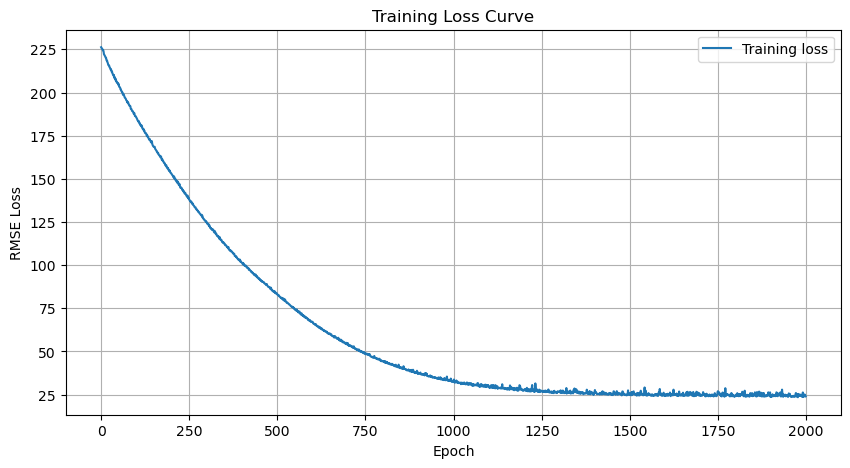

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(np.sqrt(losses), label="Training loss")
plt.xlabel("Epoch")
plt.ylabel("RMSE Loss")
plt.title("Training Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

**Висновок:**
Враховуючи кількість екземплярів у нашому наборі даних, я вважаю, що модель добре навчилась навчилась, loss вийшов на плато, хоча і значення самого loss хотілось би ще мінімізувати

Модель навчилась, але не факт, що точно)

Доволі неочікувано, що середньоквадратичне відхилення тестового набору даних буде на порядок більшим за одиниці в нашому наборі даних. Середньоквадратичне відхилення 100 означає, що прогноз і фактичне значення будуть відрізнятися в середньому на 100 (тобто, 100 000 пасажирів у цьому наборі даних).



Щоб краще зрозуміти якість прогнозу, ви можете побудувати графік з кодом нижче (а ще нижче - описано, що відбувається в цьому коді, бо це теж корисно зрозуміти):

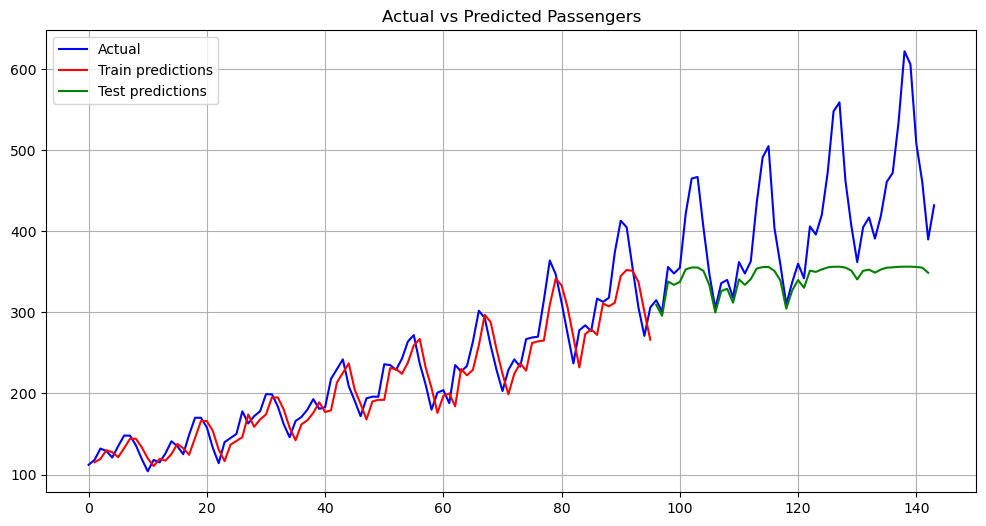

In [18]:
def plot_predicts():
    with torch.no_grad():

        # Оригінальний ряд
        series = passengers  # або df['Passengers'].values.astype(np.float32)

        # Порожні масиви для графіка
        train_plot = np.ones_like(series) * np.nan
        test_plot = np.ones_like(series) * np.nan

        # ---- TRAIN PREDICTIONS ----
        train_pred = model(X_train.reshape(-1, 1, 1)).numpy().flatten()
        train_plot[1:len(train_pred)+1] = train_pred

        # ---- TEST PREDICTIONS ----
        test_pred = model(X_test.reshape(-1, 1, 1)).numpy().flatten()
        test_plot[len(train):len(train)+len(test_pred)] = test_pred

        # ---- PLOT ----
        plt.figure(figsize=(12, 6))
        plt.plot(series, label="Actual", c='b')
        plt.plot(train_plot, label="Train predictions", c='r')
        plt.plot(test_plot, label="Test predictions", c='g')
        plt.legend()
        plt.title("Actual vs Predicted Passengers")
        plt.grid(True)
        plt.show()

plot_predicts()

In [ ]:
def plot_predicts():
  with torch.no_grad():
      # Зсув прогнозів для тренувальних даних
      train_plot = np.ones_like(timeseries) * np.nan
      y_pred = model(X_train)
      y_pred = y_pred[:, -1]
      train_plot[lookback:train_size] = model(X_train)[:, -1]

      # Зсув прогнозів для тестових даних
      test_plot = np.ones_like(timeseries) * np.nan
      test_plot[train_size+lookback:len(timeseries)] = model(X_test)[:, -1]

  # Візуалізація результатів
  plt.plot(timeseries, c='b')  # Реальні дані
  plt.plot(train_plot, c='r')  # Прогнози на тренувальних даних
  plt.plot(test_plot, c='g')   # Прогнози на тестових даних
  plt.show()

plot_predicts()

**Що відбувається в коді вище.** В цьому коді здійснюється процес прогнозування часових рядів за допомогою LSTM моделі, а також виведення графіку, який показує реальні значення, тренувальні та тестові прогнози. Ось що відбувається на кожному етапі:

1. **`torch.no_grad()`**: Цей контекстний менеджер вимикає обчислення градієнтів, що означає, що під час прогнозування не будуть зберігатися проміжні обчислення для зворотного проходу (backpropagation). Це підвищує ефективність під час прогнозування і зменшує використання пам'яті.

2. **Зсув прогнозів для тренувальних даних:**
   - Створюється масив `train_plot`, який має такий самий розмір, як і часовий ряд (`timeseries`), і заповнюється значеннями NaN (`np.nan`), щоб залишити місце для реальних значень.
   - Модель передбачає виходи для тренувальних даних `X_train`.
   - Використовується лише останнє передбачене значення для кожного входу LSTM (`y_pred[:, -1]`).
   - Прогнози зсуваються, починаючи з індексу `lookback` до кінця тренувальних даних (індекс `train_size`). Цей зсув потрібен, щоб зробити прогноз на основі попередніх даних і відобразити його на правильній частині графіку.

3. **Зсув прогнозів для тестових даних:**
   - Створюється масив `test_plot`, який також заповнюється NaN.
   - Прогнози для тестових даних додаються з індексу `train_size + lookback` до кінця реальних даних, щоб відобразити, де модель починає прогнозувати тестову вибірку.

4. **Побудова графіка:**
   - `plt.plot(timeseries, c='b')`: Виводить реальні значення часового ряду (синя лінія).
   - `plt.plot(train_plot, c='r')`: Виводить тренувальні прогнози (червона лінія).
   - `plt.plot(test_plot, c='g')`: Виводить тестові прогнози (зелена лінія).

**Чому це робиться:**
- Зсув прогнозів для тренувальних і тестових даних дозволяє візуально зрівняти, наскільки добре модель прогнозує як на тренувальній, так і на тестовій вибірках. Зазвичай, червона лінія (тренувальні прогнози) повинна точно відповідати синій лінії (реальні дані), а зелена лінія (тестові прогнози) дає змогу побачити, наскільки модель добре працює на нових даних, яких вона раніше не бачила.

**Завдання 8**. Навчіть модель з hidden_size=100 та порівняйте результати прогнозів з попередніми.

In [19]:
model = AirModel(hidden_size=100, num_layers=1)

In [20]:
# Функція втрат і оптимізатор
loss_fn = nn.MSELoss()
opt = torch.optim.Adam(model.parameters(), lr=0.001)

losses = []
epochs = 2000

for epoch in range(epochs):

    model.train()
    batch_losses = []

    for xb, yb in train_dl:
        # Перетворюємо у формат (batch, seq_len=1, input_size=1)
        xb = xb.reshape(-1, 1, 1)
        yb = yb.reshape(-1, 1)

        # Прямий прохід
        pred = model(xb)

        # Обчислення втрат
        loss = loss_fn(pred, yb)

        # Зворотний прохід
        opt.zero_grad()
        loss.backward()
        opt.step()

        batch_losses.append(loss.item())

    # Середній loss за епоху
    epoch_loss = np.mean(batch_losses)
    losses.append(epoch_loss)

    # Валідація кожні 100 епох
    if epoch % 100 == 0:
        model.eval()
        with torch.no_grad():

            # ---- TRAIN RMSE ----
            train_pred = model(X_train.reshape(-1, 1, 1))
            train_rmse = torch.sqrt(loss_fn(train_pred, y_train)).item()

            # ---- TEST RMSE ----
            test_pred = model(X_test.reshape(-1, 1, 1))
            test_rmse = torch.sqrt(loss_fn(test_pred, y_test)).item()

        print(f"Epoch {epoch}: train RMSE {train_rmse:.4f}, test RMSE {test_rmse:.4f}")

Epoch 0: train RMSE 225.6814, test RMSE 422.1042
Epoch 100: train RMSE 147.4252, test RMSE 338.8126
Epoch 200: train RMSE 99.0397, test RMSE 280.5099
Epoch 300: train RMSE 69.4105, test RMSE 236.4411
Epoch 400: train RMSE 49.3963, test RMSE 199.7823
Epoch 500: train RMSE 37.2906, test RMSE 170.6880
Epoch 600: train RMSE 31.7528, test RMSE 148.4337
Epoch 700: train RMSE 27.3254, test RMSE 131.2386
Epoch 800: train RMSE 28.1254, test RMSE 119.5187
Epoch 900: train RMSE 24.6870, test RMSE 110.2565
Epoch 1000: train RMSE 24.4154, test RMSE 105.2083
Epoch 1100: train RMSE 24.7208, test RMSE 99.7611
Epoch 1200: train RMSE 24.8337, test RMSE 99.4821
Epoch 1300: train RMSE 23.1832, test RMSE 94.3719
Epoch 1400: train RMSE 23.1024, test RMSE 93.1851
Epoch 1500: train RMSE 23.5230, test RMSE 93.8952
Epoch 1600: train RMSE 27.6997, test RMSE 94.6891
Epoch 1700: train RMSE 23.8787, test RMSE 91.5266
Epoch 1800: train RMSE 23.5626, test RMSE 87.6289
Epoch 1900: train RMSE 23.7300, test RMSE 88.5648

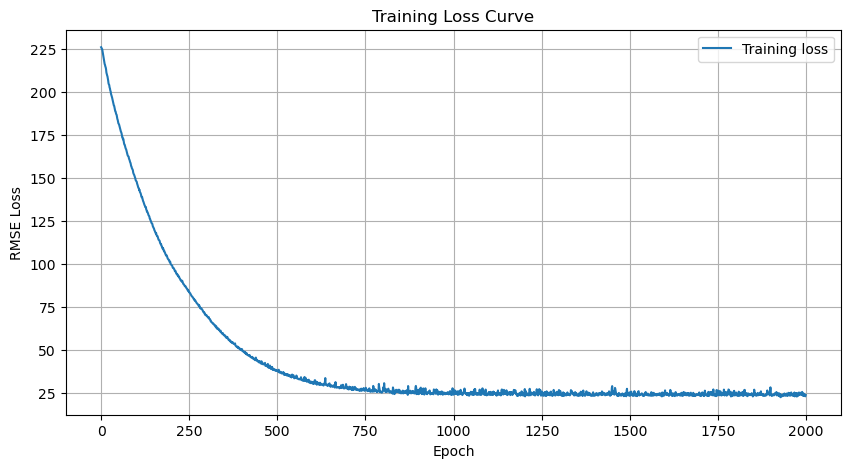

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(np.sqrt(losses), label="Training loss")
plt.xlabel("Epoch")
plt.ylabel("RMSE Loss")
plt.title("Training Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

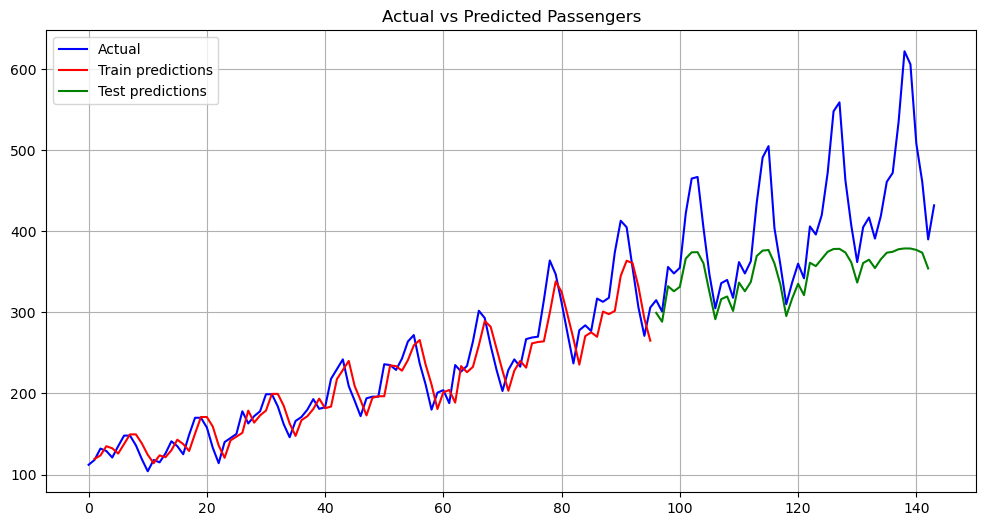

In [22]:
plot_predicts()

**Висновок**

Збільшення розміру прихованого шару LSTM з 50 до 100 покращило якість прогнозування.
Train RMSE залишився приблизно на тому ж рівні (~23), але Test RMSE зменшився з ~100 до ~88.
Це означає, що модель з більшим hidden_size краще узагальнює закономірності часового ряду і точніше прогнозує нові дані.
Перенавчання не спостерігається, оскільки різниця між train і test RMSE не зростає.

Додатково внизу спробувала на відмаштабованих даних

In [23]:
scaler = MinMaxScaler()
passengers_scaled = scaler.fit_transform(passengers.reshape(-1, 1)).flatten()

In [24]:
n = len(passengers_scaled)
split_idx = int(n * 0.67)

train = passengers_scaled[:split_idx]
test = passengers_scaled[split_idx:]

In [25]:
X_train, y_train = create_dataset(train, lookback=1)
X_test, y_test = create_dataset(test, lookback=1)

train_ds = TensorDataset(X_train, y_train)
train_dl = DataLoader(train_ds, batch_size=12, shuffle=True)

In [26]:
class AirModel(nn.Module):
    def __init__(self, hidden_size, num_layers, dropout=0.2):
        super(AirModel, self).__init__()
        
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

In [27]:
model = AirModel(hidden_size=100, num_layers=1, dropout=0.2)

In [28]:
loss_fn = nn.MSELoss()
opt = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

In [29]:
best_rmse = float('inf')
patience = 50
counter = 0

In [30]:
epochs = 2000
losses = []

for epoch in range(epochs):

    model.train()
    batch_losses = []

    for xb, yb in train_dl:
        xb = xb.reshape(-1, 1, 1)
        yb = yb.reshape(-1, 1)

        pred = model(xb)
        loss = loss_fn(pred, yb)

        opt.zero_grad()
        loss.backward()
        opt.step()

        batch_losses.append(loss.item())

    losses.append(np.mean(batch_losses))

    # ---- VALIDATION ----
    if epoch % 200 == 0:
        model.eval()
        with torch.no_grad():
            train_pred = model(X_train.reshape(-1, 1, 1))
            test_pred = model(X_test.reshape(-1, 1, 1))

            train_rmse = torch.sqrt(loss_fn(train_pred, y_train)).item()
            test_rmse = torch.sqrt(loss_fn(test_pred, y_test)).item()

        print(f"Epoch {epoch}: train RMSE {train_rmse:.4f}, test RMSE {test_rmse:.4f}")

        # ---- EARLY STOPPING ----
        if test_rmse < best_rmse:
            best_rmse = test_rmse
            counter = 0
        else:
            counter += 1

        if counter >= patience:
            print("Early stopping triggered")
            break

Epoch 0: train RMSE 0.2597, test RMSE 0.6287
Epoch 200: train RMSE 0.0444, test RMSE 0.0930
Epoch 400: train RMSE 0.0441, test RMSE 0.0941
Epoch 600: train RMSE 0.0441, test RMSE 0.0940
Epoch 800: train RMSE 0.0441, test RMSE 0.0941
Epoch 1000: train RMSE 0.0446, test RMSE 0.0994
Epoch 1200: train RMSE 0.0442, test RMSE 0.0984
Epoch 1400: train RMSE 0.0440, test RMSE 0.0967
Epoch 1600: train RMSE 0.0440, test RMSE 0.0958
Epoch 1800: train RMSE 0.0440, test RMSE 0.0966


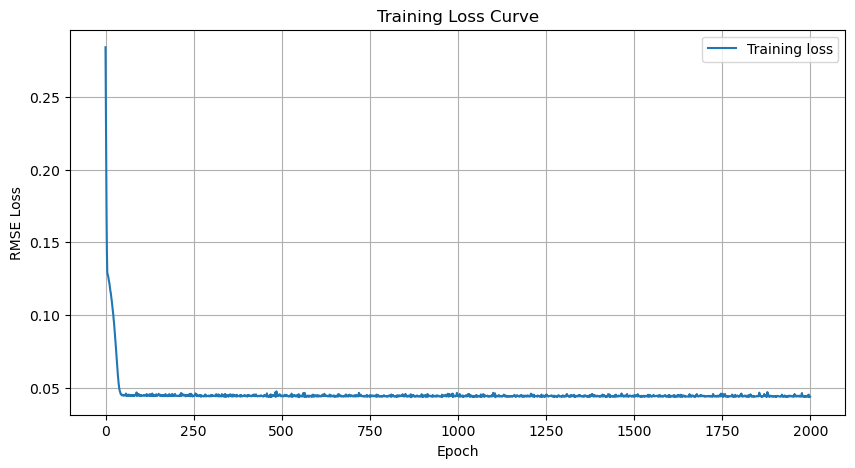

In [31]:
plt.figure(figsize=(10, 5))
plt.plot(np.sqrt(losses), label="Training loss")
plt.xlabel("Epoch")
plt.ylabel("RMSE Loss")
plt.title("Training Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

In [32]:
def plot_predictions(model, scaler, passengers_scaled, X_train, X_test, y_train, y_test):
    model.eval()
    with torch.no_grad():

        # ---- 1. Прогнози ----
        train_pred = model(X_train.reshape(-1, 1, 1)).numpy()
        test_pred = model(X_test.reshape(-1, 1, 1)).numpy()

        # ---- 2. Inverse transform ----
        train_pred_inv = scaler.inverse_transform(train_pred)
        test_pred_inv = scaler.inverse_transform(test_pred)

        y_train_inv = scaler.inverse_transform(y_train.numpy())
        y_test_inv = scaler.inverse_transform(y_test.numpy())

        # ---- 3. Підготовка масивів для графіка ----
        full_series = scaler.inverse_transform(passengers_scaled.reshape(-1, 1)).flatten()

        train_plot = np.full_like(full_series, np.nan, dtype=float)
        test_plot = np.full_like(full_series, np.nan, dtype=float)

        # Тренувальні прогнози починаються з індексу 1
        train_plot[1:len(train_pred_inv)+1] = train_pred_inv.flatten()

        # Тестові прогнози починаються після train
        test_start = len(y_train_inv) + 1
        test_plot[test_start:test_start + len(test_pred_inv)] = test_pred_inv.flatten()

        # ---- 4. Графік ----
        plt.figure(figsize=(12, 6))
        plt.plot(full_series, label="Actual", color='blue')
        plt.plot(train_plot, label="Train predictions", color='red')
        plt.plot(test_plot, label="Test predictions", color='green')
        plt.title("Actual vs Predicted Passengers")
        plt.xlabel("Time")
        plt.ylabel("Passengers")
        plt.legend()
        plt.grid(True)
        plt.show()

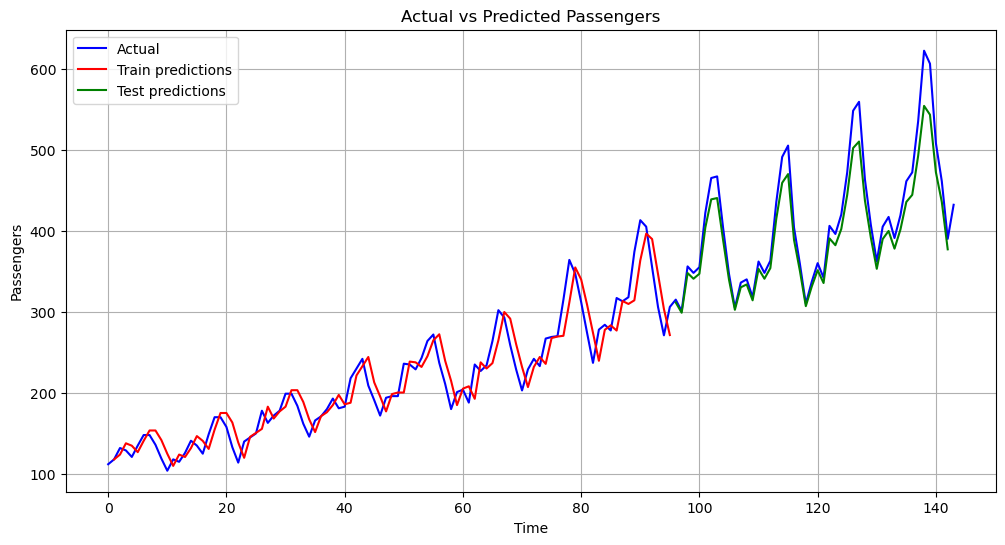

In [33]:
plot_predictions(
    model=model,
    scaler=scaler,
    passengers_scaled=passengers_scaled,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)

In [34]:
def get_inverse_predictions(model, scaler, X_train, X_test, y_train, y_test):
    model.eval()
    with torch.no_grad():
        # Прогнози
        train_pred = model(X_train.reshape(-1, 1, 1)).numpy()
        test_pred = model(X_test.reshape(-1, 1, 1)).numpy()

        # Inverse transform
        train_pred_inv = scaler.inverse_transform(train_pred)
        test_pred_inv = scaler.inverse_transform(test_pred)

        y_train_inv = scaler.inverse_transform(y_train.numpy())
        y_test_inv = scaler.inverse_transform(y_test.numpy())

    return train_pred_inv, test_pred_inv, y_train_inv, y_test_inv

In [35]:
train_pred_inv, test_pred_inv, y_train_inv, y_test_inv = get_inverse_predictions(
    model, scaler, X_train, X_test, y_train, y_test
)

In [36]:
residuals = y_test_inv.flatten() - test_pred_inv.flatten()

<Figure size 1200x400 with 0 Axes>

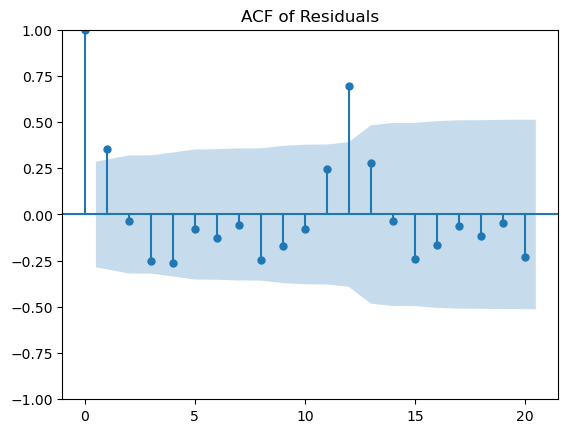

<Figure size 1200x400 with 0 Axes>

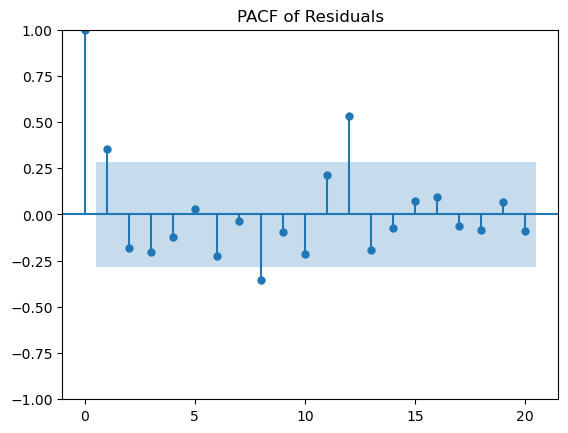

In [37]:
plt.figure(figsize=(12,4))
plot_acf(residuals, lags=20)
plt.title("ACF of Residuals")
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(residuals, lags=20, method='ywm')
plt.title("PACF of Residuals")
plt.show()

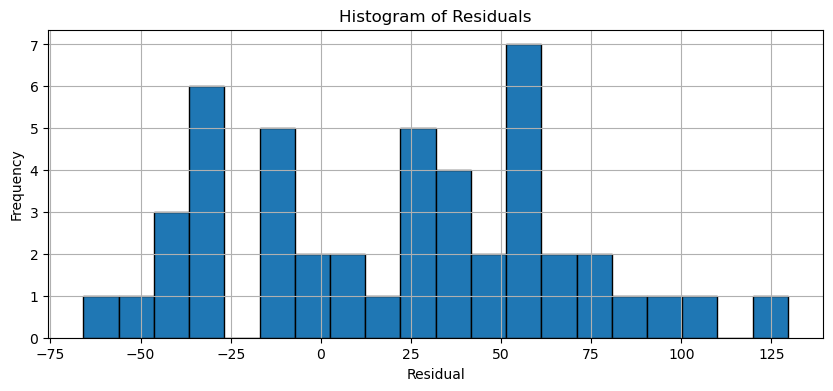

In [38]:
plt.figure(figsize=(10,4))
plt.hist(residuals, bins=20, edgecolor='black')
plt.title("Histogram of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

<Figure size 600x600 with 0 Axes>

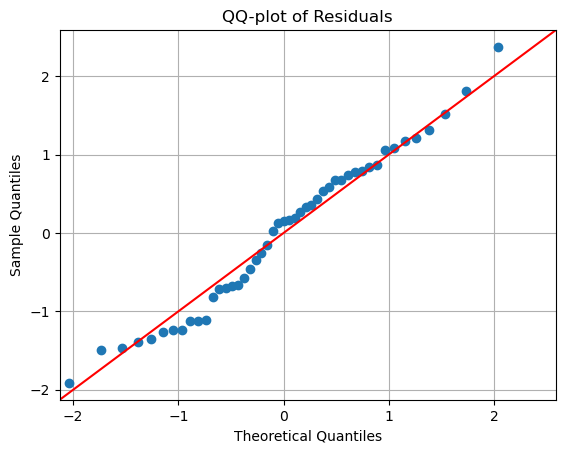

In [39]:
plt.figure(figsize=(6,6))
sm.qqplot(residuals, line='45', fit=True)
plt.title("QQ-plot of Residuals")
plt.grid(True)
plt.show()

**Висновок**

На основі аналізу ACF, PACF, гістограми та QQ‑plot залишків можна зробити однозначний висновок:
LSTM‑модель адекватно описує часовий ряд, не пропускає тренд чи сезонність, а залишки поводяться як випадковий шум.
Це означає, що модель добре узагальнює, не перенавчається і не має систематичних помилок.

Я вважаю це хороший результат для LSTM на такому невеликому датасеті (144 точки).